## About the Dataset

https://www.kaggle.com/datasets/dmahajanbe23/ai-job-replacement-and-skill-shift-dataset/data

AI Job Replacement & Skill Shift Dataset (2020–2026) — Version 2 🚀 Overview

The AI Job Replacement & Skill Shift Dataset (2020–2026) provides a structured simulation of global workforce transformation driven by artificial intelligence adoption across industries and countries.

As automation accelerates and AI systems integrate into economic processes, job roles evolve, skill requirements shift, and wage structures adjust. This dataset models these workforce dynamics using structured synthetic data designed for research, analytics, and machine learning experimentation.

Version 2 enhances the dataset with advanced engineered metrics to support classification, risk scoring, and workforce pressure modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ai_job_replacement.csv")
df

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,HR Manager,Finance,Canada,2025,44.05,38.61,1.06,74458.30,76568.31,2.83,-17.88,96.56,7.94,1,Medium,22.555,2.83,18.787,3.497570
14996,14996,Software Engineer,Energy,India,2023,15.68,15.37,34.93,97728.22,94274.12,-3.53,18.14,37.83,22.79,5,Low,25.305,3.53,17.810,3.573472
14997,14997,Truck Driver,Transportation,Japan,2026,80.16,67.09,48.57,74801.26,79989.74,6.94,26.51,41.20,10.57,3,High,64.365,6.94,48.717,8.472912
14998,14998,Customer Support Rep,Transportation,USA,2020,34.54,37.05,49.30,124632.88,127378.53,2.20,10.36,92.09,2.76,3,Medium,41.920,2.20,29.266,0.953304


In [3]:
print(df.shape)
print(df.info())

(15000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  object 
 2   industry                     15000 non-null  object 
 3   country                      15000 non-null  object 
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64
 13  ai_a

In [4]:
print(df.describe())

             job_id          year  automation_risk_percent  \
count  15000.000000  15000.000000             15000.000000   
mean    7499.500000   2022.997200                46.176347   
std     4330.271354      1.999365                21.663635   
min        0.000000   2020.000000                 5.000000   
25%     3749.750000   2021.000000                28.790000   
50%     7499.500000   2023.000000                46.235000   
75%    11249.250000   2025.000000                63.602500   
max    14999.000000   2026.000000                94.980000   

       ai_replacement_score  skill_gap_index  salary_before_usd  \
count          15000.000000     15000.000000       15000.000000   
mean              46.155907        50.003708       89771.375196   
std               22.351347        28.811040       34522.125434   
min                4.010000         0.000000       30003.690000   
25%               28.357500        25.170000       60127.225000   
50%               45.675000        49.9

In [5]:
df[df.isnull().any(axis=1)]

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity


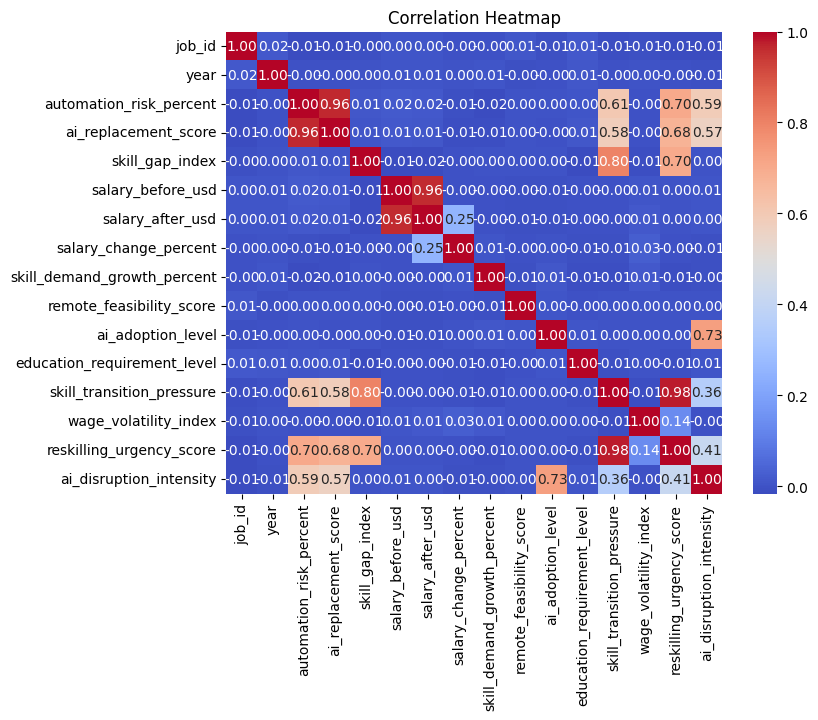

In [6]:
#corelation Heatmap

# compute correlation matrix
corr = df.corr(numeric_only=True)

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Hanlde Missing Values
There are no numm values

In [7]:
#drop unnessassary columns
df = df.drop(columns=['job_id'], axis=1)

# Finding Numeric and categorical columns

In [8]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

print('Numberic:', len(num_cols))
print('Categorical:', len(cat_cols))

print(cat_cols)



Numberic: 15
Categorical: 4
Index(['job_role', 'industry', 'country', 'automation_risk_category'], dtype='object')


## Encoding

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [10]:
from sklearn.preprocessing import LabelEncoder

# 4 categorical columns
cat_cols = ['job_role', 'industry', 'country', 'automation_risk_category']

# Encode each column in-place
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])  # fill NaNs with mode
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print(df[cat_cols].head())

   job_role  industry  country  automation_risk_category
0         2         6        2                         1
1         0         2        1                         2
2         8         6        8                         2
3         1         6        1                         2
4         8         4        5                         1


In [11]:
df

,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,2,6,2,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,1,49.710,2.34,33.150,22.711764
1,0,2,1,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,2,27.070,4.69,22.857,9.551472
2,8,6,8,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,2,37.245,10.13,28.516,11.468320
3,1,6,1,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,2,38.445,5.44,30.391,9.704860
4,8,4,5,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,1,55.555,6.01,36.591,6.404910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,4,2,2,2025,44.05,38.61,1.06,74458.30,76568.31,2.83,-17.88,96.56,7.94,1,2,22.555,2.83,18.787,3.497570
14996,7,1,4,2023,15.68,15.37,34.93,97728.22,94274.12,-3.53,18.14,37.83,22.79,5,1,25.305,3.53,17.810,3.573472
14997,9,7,5,2026,80.16,67.09,48.57,74801.26,79989.74,6.94,26.51,41.20,10.57,3,0,64.365,6.94,48.717,8.472912
14998,1,7,8,2020,34.54,37.05,49.30,124632.88,127378.53,2.20,10.36,92.09,2.76,3,2,41.920,2.20,29.266,0.953304


## Data Imputation

In [12]:
#numeric to median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill all categorical columns with mode

# Here we need to user median for categorical columns as all are now converted to numeric values
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].median())


print(df[cat_cols].head())

   job_role  industry  country  automation_risk_category
0         2         6        2                         1
1         0         2        1                         2
2         8         6        8                         2
3         1         6        1                         2
4         8         4        5                         1


In [13]:
# #print(df.isnull())
# null_rows = df[df.isnull().any(axis=1)]
# print(null_rows)

## Train_Test_Split

In [14]:
target = "ai_disruption_intensity"

In [15]:
#seperate X and Y
X = df.drop(target, axis=1)
y = df[target]

In [16]:
#Training and Testing Data (divide the data into two part)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=.3, random_state=42)

## Normalize / Standardize
I choose to standardize as in some columns we have some outliers

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.transform(X_test)

### Cross Validation
We must do cross-validation as we want to avoid overfitting
Instead of one tran/test split we will use K-fold CV as it will help us to iterate through all the datapoints in the dataset

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train models and evalaute all models one-by-one

In [19]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mae_lr = mean_absolute_error(y_test, pred_lr)
r2_lr = r2_score(y_test, pred_lr)

print("LinearRegression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)


LinearRegression
RMSE: 6.159617645576728
MAE: 4.496207337234164
R2: 0.8854450116583596


In [26]:
#KNN Regressor
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("\nKNN")

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_knn)))
print("MAE:", mean_absolute_error(y_test, pred_knn))
print("R2:", r2_score(y_test, pred_knn))



KNN
RMSE: 20.912575431370705
MAE: 16.64754735807408
R2: -0.3204487126707032


In [21]:
#DECISION Tree
#KNN Regressor
dt = DecisionTreeRegressor(max_depth=30, random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)


print("\nDecition Tree")
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_dt)))
print("MAE:", mean_absolute_error(y_test, pred_dt))
print("R2:", r2_score(y_test, pred_dt))



Decition Tree
RMSE: 0.7257926593851254
MAE: 0.4755451906666666
R2: 0.9984095074488053


In [25]:
#Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("\nRandom Forest")

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R2:", r2_score(y_test, pred_rf))



Random Forest
RMSE: 0.2929356280974472
MAE: 0.17169124306666703
R2: 0.9997409098586703


In [24]:
# AdaBoost
ada = AdaBoostRegressor(random_state=42)
ada.fit(X_train, y_train)

pred_ada = ada.predict(X_test)

print("\nAdaBoost")

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_ada)))
print("MAE:", mean_absolute_error(y_test, pred_ada))
print("R2:", r2_score(y_test, pred_ada))



AdaBoost
RMSE: 3.1050772126564525
MAE: 2.591635924429751
R2: 0.970889390085506


In [25]:
results = {
    "Linear": rmse_lr,
    "KNN": np.sqrt(mean_squared_error(y_test, pred_knn)),
    "Tree": np.sqrt(mean_squared_error(y_test, pred_dt)),
    "RF": np.sqrt(mean_squared_error(y_test, pred_rf)),
    "Ada": np.sqrt(mean_squared_error(y_test, pred_ada))
}

print(results)

{'Linear': np.float64(6.159617645576728), 'KNN': np.float64(19.799260274865855), 'Tree': np.float64(0.7257926593851254), 'RF': np.float64(19.799260274865855), 'Ada': np.float64(3.1050772126564525)}


✅ How to compare
For regression:
RMSE ↓ (most important)
lower = better

MAE ↓
lower = better

R² ↑
closer to 1 = better